# Ciencia de datos para un taller de calzado

**¿Qué clientes no van a regresar, cuánto trabajo viene y cuánto vale cada cliente?**

Este proyecto usa los datos que genera el [sistema de taller y ventas](#) que diseñé y desarrollé para la zapatería de mi familia. El sistema exporta dos archivos (`Reparaciones.csv` y `Ventas y cobros.csv`) y este notebook los convierte en decisiones:

1. **Modelo de abandono**: predice qué clientes no regresarán en los próximos 6 meses, para contactarlos antes de perderlos.
2. **Segmentación y valor del cliente**: clasifica a la clientela por comportamiento y estima cuánto vale cada persona en los próximos 12 meses.
3. **Pronóstico de demanda**: anticipa cuántos trabajos llegarán al taller cada semana, para planear personal y materiales.

### Resultados principales
| Pregunta | Resultado |
|---|---|
| ¿Quién no va a regresar? | El modelo (regresión logística, **ROC AUC 0.66**) empata con la regla "días sin venir" (0.67): buena parte del abandono en un servicio ocasional es impredecible. Su aporte está en dar **probabilidades calibradas** y en medir factores que el negocio controla. |
| ¿Qué causa el abandono? | Además del tiempo sin venir, **entregar tarde** se asocia con **+23 puntos porcentuales** más de abandono, y los retrasos se disparan en las semanas saturadas. |
| ¿Cuánto vale cada cliente? | El segmento *Campeones* concentra el **60%** del valor futuro. **13 clientes** de alto valor y alto riesgo suman **$5,133** de ingreso esperado a 12 meses; el notebook exporta esa lista para cargarla como campaña. |
| ¿Cuánto trabajo viene? | A 8 semanas, error de **±5.6 trabajos por semana**, suficiente para anticipar la temporada alta. Semana a semana, la variación es casi toda ruido natural. |


> **Sobre los datos.** El sistema empezó a usarse recientemente, así que este análisis corre sobre **dos años de datos simulados** con el formato exacto del sistema (ver `simular_datos.py`). El simulador sigue un modelo BG/NBD de comportamiento de clientes e incluye efectos conocidos (estacionalidad, saturación del taller y el impacto de los retrasos). Esto permite algo que con datos reales no se puede: **verificar que el método recupera patrones que sabemos que existen**. Cuando haya suficientes datos reales, basta con cambiar la carpeta `DATOS` y volver a ejecutar.

## 1. Carga y revisión de los datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

DATOS = Path("datos")          # carpeta con los CSV exportados desde el sistema
HOY = pd.Timestamp("2026-09-27")  # fecha de corte del análisis (con datos reales: la fecha de exportación)

CAFE, HILO, AZUL, VERDE, ROJO, GRIS = "#5E311A", "#E3AE36", "#2C6DAA", "#23875A", "#C0333A", "#98A0A6"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": .25, "axes.titleweight": "bold", "axes.titlesize": 12,
                     "font.size": 10, "axes.prop_cycle": plt.cycler(color=[CAFE, HILO, AZUL, VERDE, ROJO])})
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

fechas = ["Recibido", "Entrega prometida", "Listo", "Entregado"]
rep = pd.read_csv(DATOS / "Reparaciones.csv", parse_dates=fechas, dtype={"Teléfono": str})
caja = pd.read_csv(DATOS / "Ventas y cobros.csv", parse_dates=["Fecha"])

print(f"Reparaciones: {len(rep):,}  |  del {rep.Recibido.min():%d %b %Y} al {rep.Recibido.max():%d %b %Y}")
print(f"Movimientos de caja: {len(caja):,}")
display(rep.head(3))

Reparaciones: 2,809  |  del 01 Oct 2024 al 26 Sep 2026
Movimientos de caja: 5,692


,Folio,Cliente,Teléfono,Calzado,Trabajos,Observaciones,Precio,Anticipo,Pagado al entregar,Resta,Estado,Recibido,Entrega prometida,Listo,Entregado
0,R-0001,Silvia Cruz Álvarez,5537044048,Zapatos de vestir vino,Tapas,NaN,100,100,0,0,Entregado,2024-10-01,2024-10-04,2024-10-05,2024-10-05
1,R-0002,Eduardo Juárez Cruz,5557499148,Zapatillas blancos,Tapas,NaN,60,30,30,0,Entregado,2024-10-01,2024-10-03,2024-10-03,2024-10-03
2,R-0003,Pedro Torres Aguilar,NaN,Botas de trabajo café,Pegado; Limpieza y lustrado; Tapas,NaN,240,240,0,0,Entregado,2024-10-01,2024-10-03,2024-10-03,2024-10-03


In [2]:
# Revisión de calidad: lo que falta, lo que no cuadra
calidad = pd.Series({
    "Notas sin teléfono": rep["Teléfono"].isna().mean(),
    "Folios duplicados": rep["Folio"].duplicated().mean(),
    "Precio en cero o negativo": (rep["Precio"] <= 0).mean(),
    "Listo antes de recibirse": (rep["Listo"] < rep["Recibido"]).mean(),
    "Entregado sin marcar listo": (rep["Entregado"].notna() & rep["Listo"].isna()).mean(),
}).rename("% de notas").to_frame()
display(calidad.style.format("{:.1%}"))
print(rep["Estado"].value_counts().to_string())

,% de notas
Notas sin teléfono,17.9%
Folios duplicados,0.0%
Precio en cero o negativo,0.0%
Listo antes de recibirse,0.0%
Entregado sin marcar listo,0.0%


Estado
Entregado              2776
En reparación            14
Listo para entregar      13
Recibido                  6


Los datos están limpios salvo por un **~15% de notas sin teléfono**. No es un error de captura sino una pérdida de negocio: sin teléfono no hay forma de volver a contactar a ese cliente. Es la primera recomendación operativa: pedir el WhatsApp siempre al recibir el calzado.

## 2. ¿Cómo se comporta el taller?

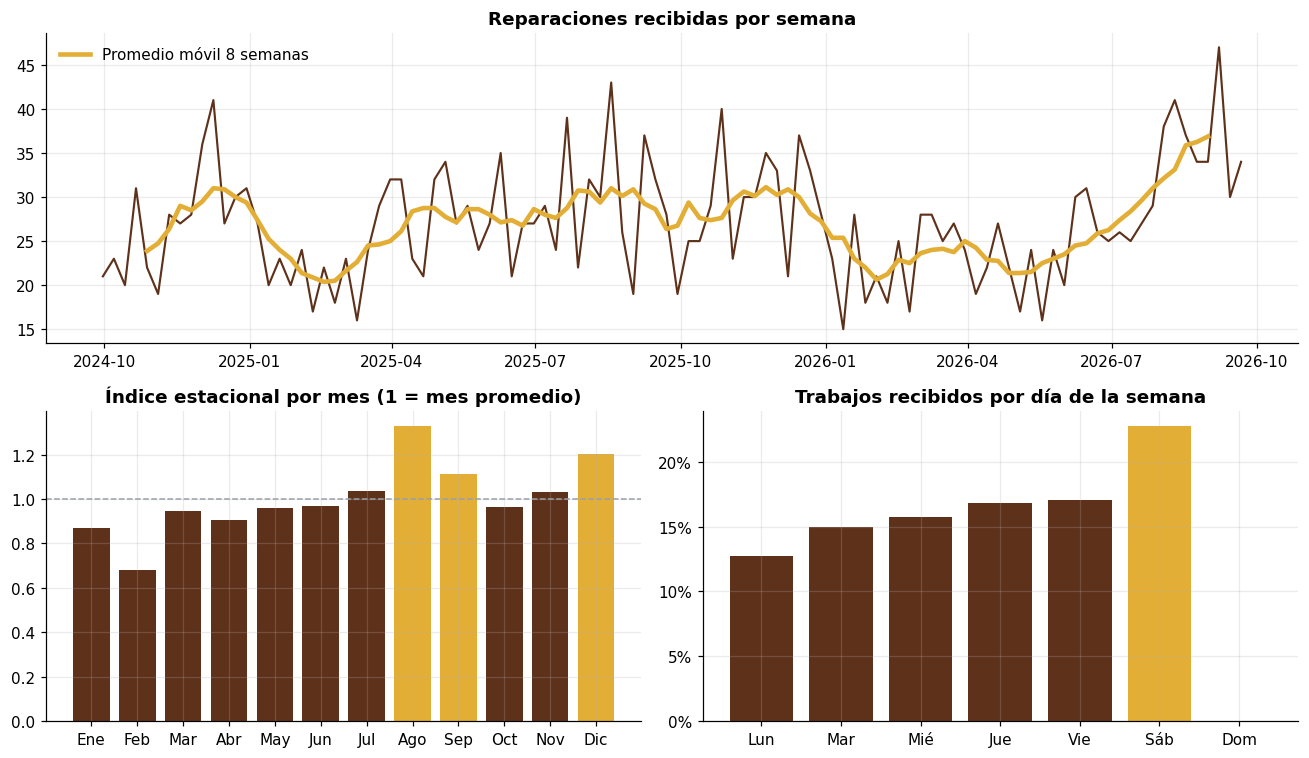

Promedio: 27.0 trabajos por semana. Semana más cargada: 47 (07 Sep 2026).


In [3]:
sem = rep.set_index("Recibido").resample("W-MON", label="left", closed="left").size()
mes_idx = rep.groupby(rep.Recibido.dt.month).size() / rep.Recibido.dt.to_period("M").nunique() * 12
mes_idx = mes_idx / mes_idx.mean()
dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
dia = rep.Recibido.dt.dayofweek.value_counts().reindex(range(7), fill_value=0) / len(rep)

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(2, 1, 1)
ax.plot(sem.index, sem.values, color=CAFE, lw=1.4)
ax.plot(sem.index, sem.rolling(8, center=True).mean(), color=HILO, lw=3, label="Promedio móvil 8 semanas")
ax.set_title("Reparaciones recibidas por semana"); ax.legend(frameon=False)
ax2 = fig.add_subplot(2, 2, 3)
meses = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
ax2.bar(meses, mes_idx.reindex(range(1, 13)).values, color=[HILO if v > 1.1 else CAFE for v in mes_idx.reindex(range(1,13))])
ax2.axhline(1, color=GRIS, ls="--", lw=1); ax2.set_title("Índice estacional por mes (1 = mes promedio)")
ax3 = fig.add_subplot(2, 2, 4)
ax3.bar(dias, dia.values, color=[HILO if d == 5 else CAFE for d in range(7)])
ax3.yaxis.set_major_formatter(mtick.PercentFormatter(1, 0)); ax3.set_title("Trabajos recibidos por día de la semana")
plt.tight_layout(); plt.show()
print(f"Promedio: {sem.mean():.1f} trabajos por semana. Semana más cargada: {sem.max()} ({sem.idxmax():%d %b %Y}).")

Tres patrones claros: **agosto y diciembre** son los meses fuertes (regreso a clases y fiestas), junio a septiembre también sube con la temporada de lluvias, y el **sábado concentra casi una cuarta parte del trabajo**. Enero y febrero son la temporada baja: el momento ideal para campañas de reactivación.

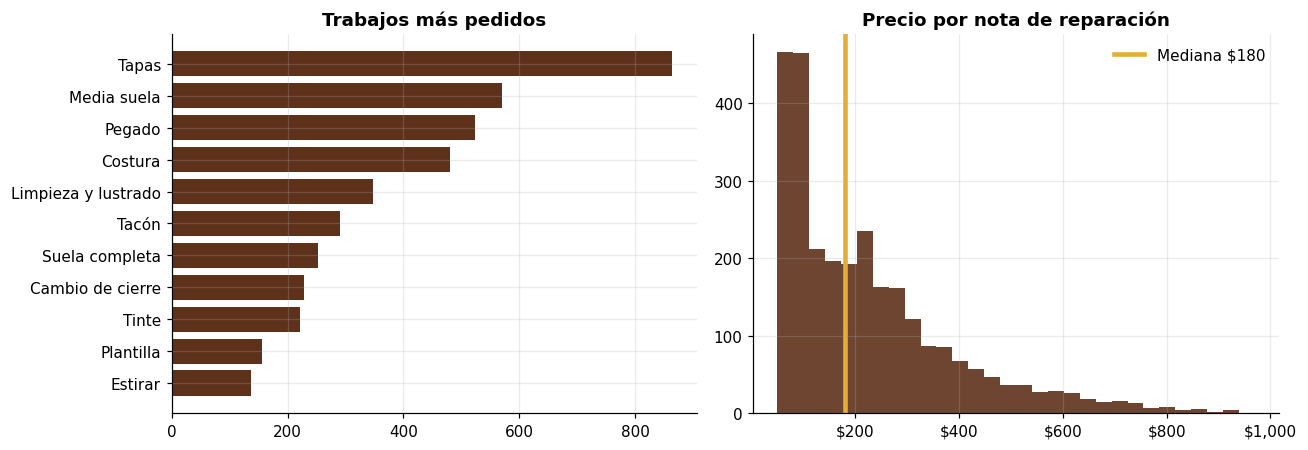

Ingreso mensual promedio: {'Taller': '$26,370', 'Venta': '$34,920'}


In [4]:
trab = rep["Trabajos"].str.split("; ").explode().value_counts()
fig, (a, b) = plt.subplots(1, 2, figsize=(12, 4.2))
a.barh(trab.index[::-1], trab.values[::-1], color=CAFE); a.set_title("Trabajos más pedidos")
b.hist(rep["Precio"], bins=30, color=CAFE, alpha=.9)
b.axvline(rep["Precio"].median(), color=HILO, lw=3, label=f"Mediana ${rep['Precio'].median():,.0f}")
b.set_title("Precio por nota de reparación"); b.legend(frameon=False); b.xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
plt.tight_layout(); plt.show()

ing = caja.groupby([caja.Fecha.dt.to_period("M"), "Tipo"])["Monto"].sum().unstack().fillna(0)
print("Ingreso mensual promedio:", ing.mean().map("${:,.0f}".format).to_dict())

### ¿Entregamos a tiempo?

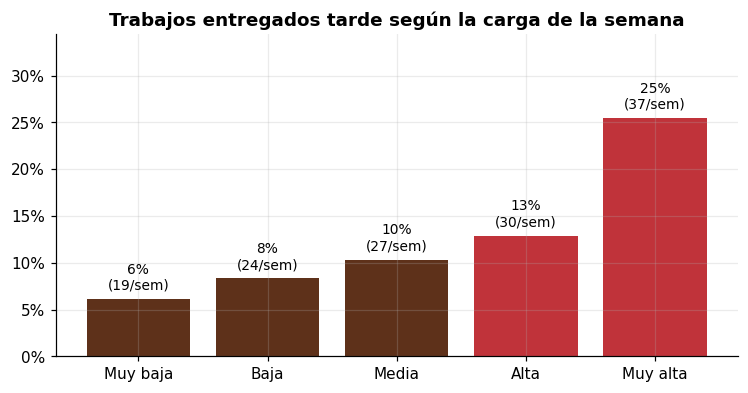

En general se entrega tarde el 14% de los trabajos.


In [5]:
term = rep.dropna(subset=["Listo"]).copy()
term["tarde"] = term["Listo"] > term["Entrega prometida"]
term["semana"] = term["Recibido"].dt.to_period("W")
carga = term.groupby("semana").agg(trabajos=("Folio", "size"), pct_tarde=("tarde", "mean"))
carga["nivel"] = pd.qcut(carga["trabajos"], 5, labels=["Muy baja", "Baja", "Media", "Alta", "Muy alta"])
por_nivel = carga.groupby("nivel", observed=True).agg(trabajos=("trabajos", "mean"), pct_tarde=("pct_tarde", "mean"))

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(por_nivel.index.astype(str), por_nivel["pct_tarde"], color=[CAFE, CAFE, CAFE, ROJO, ROJO])
for i, (t, p) in enumerate(zip(por_nivel["trabajos"], por_nivel["pct_tarde"])):
    ax.text(i, p + .01, f"{p:.0%}\n({t:.0f}/sem)", ha="center", fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, 0)); ax.set_ylim(0, por_nivel["pct_tarde"].max() * 1.35)
ax.set_title("Trabajos entregados tarde según la carga de la semana"); plt.show()
print(f"En general se entrega tarde el {term['tarde'].mean():.0%} de los trabajos.")

**El retraso no es constante: se dispara cuando el taller se satura.** En las semanas más cargadas, una proporción mucho mayor de trabajos sale tarde. Esto conecta directamente con la siguiente sección: los retrasos resultan ser uno de los factores que más predicen que un cliente no regrese.

## 3. Modelo de abandono de clientes

### Definición del problema
En un taller no hay "cancelación de suscripción": el cliente simplemente deja de venir. Por eso defino el abandono con una **ventana de observación**:

> En una fecha de corte, un cliente **abandona** si no trae ningún trabajo en los **180 días siguientes**.

Las variables se calculan solo con información disponible **hasta** la fecha de corte, y la validación es **temporal**: entreno con cortes pasados y evalúo en un corte posterior. Así se evita la fuga de información del futuro, el error más común en este tipo de modelos.

In [6]:
def clave_cliente(df):
    tel = df["Teléfono"].fillna("").str.replace(r"\D", "", regex=True).str[-10:]
    nom = df["Cliente"].str.lower().str.normalize("NFKD").str.encode("ascii", "ignore").str.decode("ascii").str.strip()
    return np.where(tel.str.len() == 10, "t" + tel, "n" + nom)

rep["cliente_id"] = clave_cliente(rep)
rep["tarde"] = rep["Listo"] > rep["Entrega prometida"]
rep["espera_recoger"] = (rep["Entregado"] - rep["Listo"]).dt.days
TRABAJOS_GRANDES = ["Suela completa", "Media suela", "Tinte", "Cambio de cierre"]

def variables(rep, corte, horizonte=180):
    """Tabla de clientes con variables al día `corte` y etiqueta de abandono en (corte, corte+horizonte]."""
    corte = pd.Timestamp(corte)
    h = rep[rep["Recibido"] <= corte].copy()
    conocido = h["Listo"].notna() & (h["Listo"] <= corte)       # solo retrasos ya observables en el corte
    h["tarde_obs"] = h["tarde"] & conocido
    h["grande"] = h["Trabajos"].str.contains("|".join(TRABAJOS_GRANDES))
    h = h.sort_values("Recibido")
    g = h.groupby("cliente_id")
    X = pd.DataFrame({
        "recencia_dias": (corte - g["Recibido"].max()).dt.days,
        "antiguedad_dias": (corte - g["Recibido"].min()).dt.days,
        "visitas": g.size(),
        "gasto_total": g["Precio"].sum(),
        "ticket_promedio": g["Precio"].mean(),
        "pct_tarde": g["tarde_obs"].mean(),
        "ultima_tarde": g["tarde_obs"].last().astype(int),
        "pct_trabajos_grandes": g["grande"].mean(),
        "espera_recoger_prom": g["espera_recoger"].mean(),
        "tiene_telefono": g["Teléfono"].last().notna().astype(int),
    })
    X["intervalo_prom"] = np.where(X["visitas"] > 1, X["antiguedad_dias"] / (X["visitas"] - 1), np.nan)
    X["recencia_vs_intervalo"] = X["recencia_dias"] / X["intervalo_prom"]
    X["espera_recoger_prom"] = X["espera_recoger_prom"].fillna(X["espera_recoger_prom"].median())
    fut = rep[(rep["Recibido"] > corte) & (rep["Recibido"] <= corte + pd.Timedelta(days=horizonte))]
    X["abandona"] = (~X.index.isin(fut["cliente_id"])).astype(int)
    X["corte"] = corte
    return X

CORTES_ENTRENAMIENTO = pd.date_range("2025-03-31", "2025-09-30", freq="ME")  # 7 cortes mensuales
CORTE_PRUEBA = "2026-03-29"   # su ventana de 180 días termina justo al final de los datos
entrena = pd.concat([variables(rep, c) for c in CORTES_ENTRENAMIENTO])
prueba = variables(rep, CORTE_PRUEBA)
resumen = pd.DataFrame({"clientes": [len(entrena), len(prueba)], "% abandona": [entrena.abandona.mean(), prueba.abandona.mean()]},
                       index=[f"Entrenamiento ({len(CORTES_ENTRENAMIENTO)} cortes)", "Prueba"])
display(resumen.style.format({"clientes": "{:,}", "% abandona": "{:.1%}"}))

,clientes,% abandona
Entrenamiento (7 cortes),"4,162",64.4%
Prueba,954,71.8%


La mayoría de los clientes no regresa en un periodo de 6 meses, lo cual es normal en un servicio de uso ocasional. Lo importante no es la tasa en sí, sino **distinguir a quién vale la pena contactar**. Comparo tres enfoques de complejidad creciente:

1. **Regla simple** (línea base): ordenar por días desde la última visita. Es lo que haría cualquier dueño con intuición.
2. **Regresión logística**: interpretable, con transformación logarítmica de las variables sesgadas.
3. **Gradient boosting**: captura relaciones no lineales e interacciones.

,ROC AUC,PR AUC,Lift en el 20% de mayor riesgo,Brier (menor es mejor)
Regla: días sin venir,0.666,0.820,1.246,n/a
Regresión logística,0.665,0.819,1.143,0.190
Gradient boosting,0.640,0.810,1.151,0.199


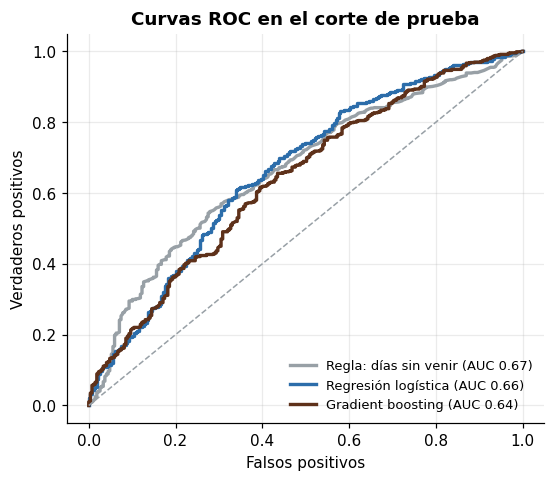

In [7]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, roc_curve

VARS = ["recencia_dias", "antiguedad_dias", "visitas", "gasto_total", "ticket_promedio", "pct_tarde", "ultima_tarde",
        "pct_trabajos_grandes", "espera_recoger_prom", "tiene_telefono", "intervalo_prom", "recencia_vs_intervalo"]
Xtr, ytr = entrena[VARS], entrena["abandona"]
Xte, yte = prueba[VARS], prueba["abandona"]

log1p = FunctionTransformer(lambda X: np.log1p(np.clip(X, 0, None)), feature_names_out="one-to-one")
modelos = {
    "Regresión logística": make_pipeline(SimpleImputer(strategy="median"), log1p, StandardScaler(), LogisticRegression(C=0.5, max_iter=2000)),
    "Gradient boosting": HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=300,
                                                        min_samples_leaf=40, l2_regularization=1.0, random_state=0),
}
prob = {"Regla: días sin venir": (Xte["recencia_dias"] / Xte["recencia_dias"].max()).values}
# Nota: un mismo cliente aparece en varios cortes de entrenamiento; la prueba es un corte posterior a todos ellos.
for n, m in modelos.items():
    m.fit(Xtr, ytr); prob[n] = m.predict_proba(Xte)[:, 1]

def lift_top(y, p, frac=.2):
    k = int(len(y) * frac); idx = np.argsort(-p)[:k]
    return y.values[idx].mean() / y.mean()

metr = pd.DataFrame({n: {"ROC AUC": roc_auc_score(yte, p), "PR AUC": average_precision_score(yte, p),
                         "Lift en el 20% de mayor riesgo": lift_top(yte, p),
                         "Brier (menor es mejor)": brier_score_loss(yte, p) if "Regla" not in n else np.nan}
                     for n, p in prob.items()}).T
display(metr.style.format("{:.3f}", na_rep="n/a").highlight_max(subset=["ROC AUC", "PR AUC"], color="#FCF2DB"))

fig, ax = plt.subplots(figsize=(5.6, 4.6))
for (n, p), c in zip(prob.items(), [GRIS, AZUL, CAFE]):
    f, t, _ = roc_curve(yte, p); ax.plot(f, t, color=c, lw=2.2, label=f"{n} (AUC {roc_auc_score(yte, p):.2f})")
ax.plot([0, 1], [0, 1], ls="--", color=GRIS, lw=1); ax.set_xlabel("Falsos positivos"); ax.set_ylabel("Verdaderos positivos")
ax.set_title("Curvas ROC en el corte de prueba"); ax.legend(frameon=False, fontsize=8.5, loc="lower right"); plt.show()

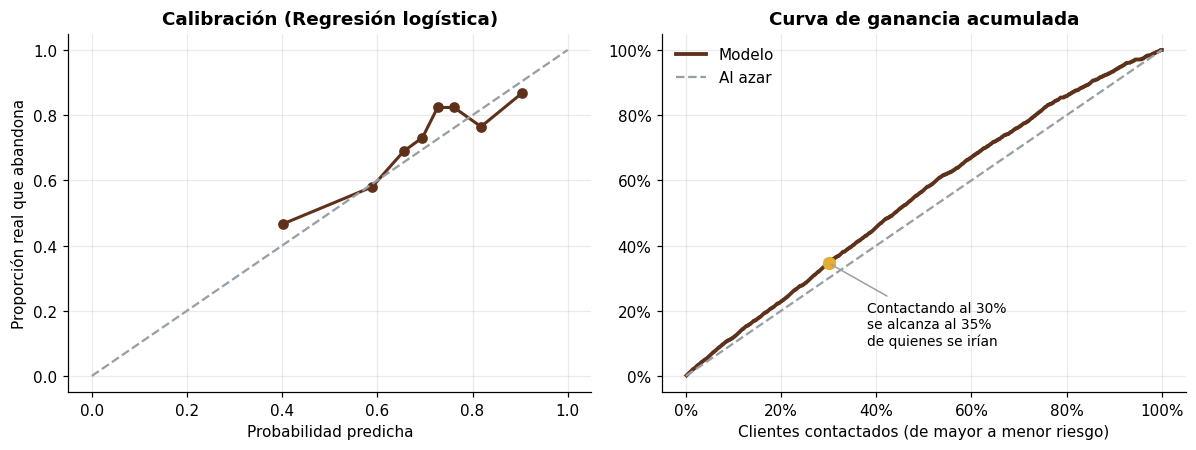

In [8]:
# Calibración y curva de ganancia: ¿cuántos de los que se van alcanzo si contacto al X% de mayor riesgo?
from sklearn.calibration import calibration_curve
mejor = max(modelos, key=lambda n: roc_auc_score(yte, prob[n]))
p = prob[mejor]
fig, (a, b) = plt.subplots(1, 2, figsize=(11, 4.2))
fr, mr = calibration_curve(yte, p, n_bins=8, strategy="quantile")
a.plot(mr, fr, "o-", color=CAFE, lw=2); a.plot([0, 1], [0, 1], ls="--", color=GRIS)
a.set_xlabel("Probabilidad predicha"); a.set_ylabel("Proporción real que abandona"); a.set_title(f"Calibración ({mejor})")

orden = np.argsort(-p); cap = np.cumsum(yte.values[orden]) / yte.sum(); x = np.arange(1, len(p) + 1) / len(p)
a2 = b; a2.plot(x, cap, color=CAFE, lw=2.5, label="Modelo"); a2.plot([0, 1], [0, 1], ls="--", color=GRIS, label="Al azar")
k = .3; cap_k = cap[int(len(p) * k) - 1]
a2.scatter([k], [cap_k], color=HILO, zorder=3, s=60); a2.annotate(f"Contactando al {k:.0%}\nse alcanza al {cap_k:.0%}\nde quienes se irían", (k, cap_k), (k + .08, cap_k - .25), fontsize=9, arrowprops=dict(arrowstyle="-", color=GRIS))
a2.xaxis.set_major_formatter(mtick.PercentFormatter(1, 0)); a2.yaxis.set_major_formatter(mtick.PercentFormatter(1, 0))
a2.set_xlabel("Clientes contactados (de mayor a menor riesgo)"); a2.set_title("Curva de ganancia acumulada"); a2.legend(frameon=False)
plt.tight_layout(); plt.show()

**El modelo (0.66) no supera de forma relevante a la regla simple (0.67) para ordenar clientes, y eso es un resultado importante.** En un servicio de uso ocasional, gran parte del "abandono" a 6 meses no es que el cliente se haya ido, sino que no se le rompió nada en ese tiempo. Ese componente es aleatorio y ningún modelo lo puede predecir, lo que pone un techo bajo a cualquier métrica de ordenamiento.

Entonces, ¿para qué sirve el modelo? Para dos cosas que la regla no puede hacer:

1. **Dar probabilidades calibradas.** La regla solo ordena; el modelo dice *cuánto* riesgo hay (la gráfica de calibración siguiente muestra que sus probabilidades coinciden con lo observado). Eso es indispensable para calcular el valor esperado de cada cliente en la sección 4.
2. **Medir el efecto de factores que el negocio controla**, como la puntualidad. La regla "días sin venir" no tiene nada que decir sobre qué hacer distinto.

La lección práctica: si solo se quisiera una lista de a quién escribir, la regla simple basta. Un modelo más complejo se justifica por las preguntas adicionales que responde, no por una mejora marginal en AUC.

### ¿Qué impulsa el abandono?

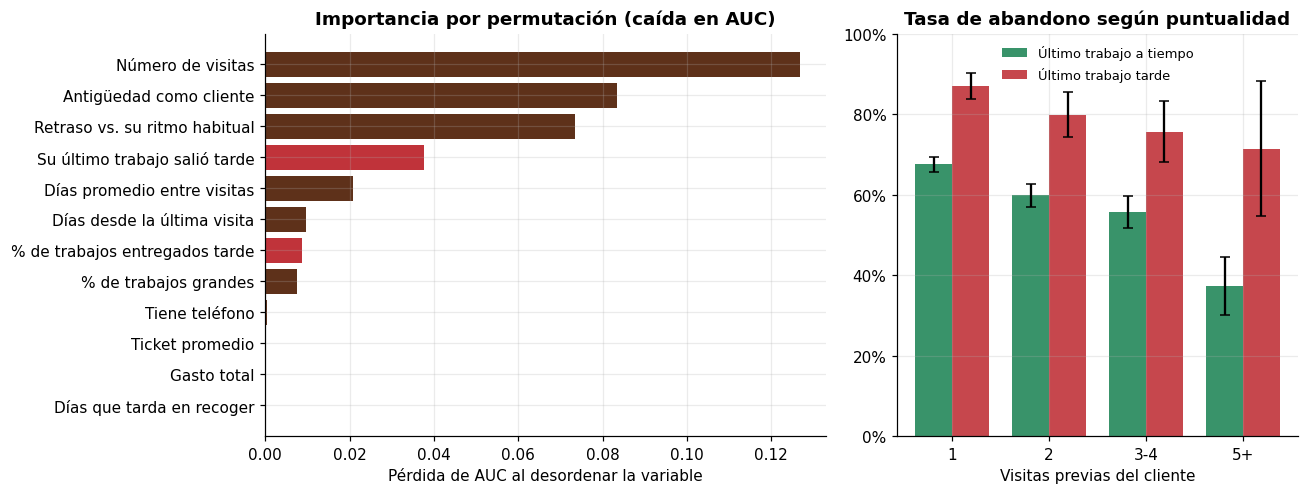

Entregar tarde se asocia con +23 puntos porcentuales de abandono, en promedio, comparando clientes con el mismo número de visitas.


In [9]:
from sklearn.inspection import permutation_importance
imp = permutation_importance(modelos[mejor], Xte, yte, scoring="roc_auc", n_repeats=15, random_state=0)
imp = pd.Series(imp.importances_mean, index=VARS).sort_values()
nombres = {"recencia_dias": "Días desde la última visita", "antiguedad_dias": "Antigüedad como cliente", "visitas": "Número de visitas",
           "gasto_total": "Gasto total", "ticket_promedio": "Ticket promedio", "pct_tarde": "% de trabajos entregados tarde",
           "ultima_tarde": "Su último trabajo salió tarde", "pct_trabajos_grandes": "% de trabajos grandes",
           "espera_recoger_prom": "Días que tarda en recoger", "tiene_telefono": "Tiene teléfono",
           "intervalo_prom": "Días promedio entre visitas", "recencia_vs_intervalo": "Retraso vs. su ritmo habitual"}

fig, (a, b) = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [1.4, 1]})
a.barh([nombres[i] for i in imp.index], imp.values, color=[ROJO if "tarde" in i else CAFE for i in imp.index])
a.set_title("Importancia por permutación (caída en AUC)"); a.set_xlabel("Pérdida de AUC al desordenar la variable")

# Efecto del retraso comparando clientes con historial similar (misma cantidad de visitas)
base = pd.concat([entrena, prueba]); base = base[base["ultima_tarde"].notna()]
base["grupo_visitas"] = pd.cut(base["visitas"], [0, 1, 2, 4, 100], labels=["1", "2", "3-4", "5+"])
tab = base.groupby(["grupo_visitas", "ultima_tarde"], observed=True)["abandona"].agg(["mean", "count"]).unstack()
xs = np.arange(len(tab)); w = .38
for j, (c, lab) in enumerate([(VERDE, "Último trabajo a tiempo"), (ROJO, "Último trabajo tarde")]):
    m, n = tab[("mean", j)], tab[("count", j)]; err = 1.96 * np.sqrt(m * (1 - m) / n)
    b.bar(xs + (j - .5) * w, m, w, yerr=err, color=c, label=lab, capsize=3, alpha=.9)
b.set_xticks(xs, tab.index.astype(str)); b.set_xlabel("Visitas previas del cliente"); b.set_ylim(0, 1)
b.yaxis.set_major_formatter(mtick.PercentFormatter(1, 0)); b.set_title("Tasa de abandono según puntualidad"); b.legend(frameon=False, fontsize=8.5)
plt.tight_layout(); plt.show()
dif = (tab[("mean", 1)] - tab[("mean", 0)]).mean()
print(f"Entregar tarde se asocia con {dif*100:+.0f} puntos porcentuales de abandono, en promedio, comparando clientes con el mismo número de visitas.")

**Hallazgos del modelo de abandono**

- Lo más predictivo es, con mucha diferencia, **el tiempo desde la última visita**, seguido del gasto acumulado. Variables más elaboradas, como el retraso respecto al ritmo habitual de cada cliente, casi no aportan información adicional.
- **Entregar tarde se asocia con más abandono**, incluso comparando clientes con el mismo historial. Unido a la sección 2 (los retrasos se disparan con la saturación), sugiere una cadena causal que vale la pena atender: *semana saturada → retraso → cliente perdido*.
- Como los datos son simulados y este efecto se incluyó a propósito en el simulador, lo relevante aquí es que **el método lo detectó sin saberlo de antemano**. Con datos reales habrá que confirmarlo; si se sostiene, la inversión en puntualidad tiene un retorno medible.

## 4. Segmentación y valor de cada cliente

Para que el modelo se convierta en acciones, combino dos cosas para cada cliente activo hoy:

- **Segmento RFM** (recencia, frecuencia, valor monetario), una técnica estándar de marketing, fácil de explicar al dueño.
- **Valor esperado a 12 meses**: visitas esperadas según su ritmo histórico × probabilidad de que siga activo × ticket promedio.

In [10]:
hoy = variables(rep, HOY, horizonte=0).drop(columns=["abandona", "corte"])
modelo_final = modelos[mejor].fit(pd.concat([entrena, prueba])[VARS], pd.concat([entrena, prueba])["abandona"])
hoy["prob_abandono"] = modelo_final.predict_proba(hoy[VARS])[:, 1]

# RFM por quintiles (5 = mejor)
hoy["R"] = pd.qcut(hoy["recencia_dias"].rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)
hoy["F"] = pd.qcut(hoy["visitas"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
hoy["M"] = pd.qcut(hoy["gasto_total"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
def segmento(r):
    if r.R >= 4 and r.F >= 4: return "Campeones"
    if r.R >= 3 and r.F >= 3: return "Leales"
    if r.R >= 4 and r.F <= 2: return "Nuevos"
    if r.R <= 2 and r.F >= 3: return "En riesgo (valiosos)"
    if r.R == 3: return "Por dormirse"
    return "Dormidos"
hoy["segmento"] = hoy.apply(segmento, axis=1)

# Valor esperado a 12 meses
anios = np.maximum(hoy["antiguedad_dias"], 90) / 365
hoy["visitas_por_anio"] = np.where(hoy["visitas"] > 1, (hoy["visitas"] - 1) / anios, 1.0)
hoy["valor_12m"] = hoy["visitas_por_anio"] * (1 - hoy["prob_abandono"]) * hoy["ticket_promedio"]

orden_seg = ["Campeones", "Leales", "Nuevos", "Por dormirse", "En riesgo (valiosos)", "Dormidos"]
tabla = hoy.groupby("segmento").agg(clientes=("visitas", "size"), visitas_prom=("visitas", "mean"), dias_sin_venir=("recencia_dias", "median"),
                                    riesgo_prom=("prob_abandono", "mean"), valor_12m=("valor_12m", "sum")).reindex(orden_seg)
tabla["% del valor futuro"] = tabla["valor_12m"] / tabla["valor_12m"].sum()
display(tabla.style.format({"clientes": "{:,}", "visitas_prom": "{:.1f}", "dias_sin_venir": "{:.0f}", "riesgo_prom": "{:.0%}",
                            "valor_12m": "${:,.0f}", "% del valor futuro": "{:.0%}"}))

,clientes,visitas_prom,dias_sin_venir,riesgo_prom,valor_12m,% del valor futuro
segmento,,,,,,
Campeones,240,4.6,46,52%,"$99,520",60%
Leales,238,2.8,197,70%,"$31,628",19%
Nuevos,139,1.0,55,67%,"$10,772",7%
Por dormirse,81,1.0,260,76%,"$4,095",2%
En riesgo (valiosos),220,2.6,480,83%,"$8,263",5%
Dormidos,246,1.0,520,80%,"$11,423",7%


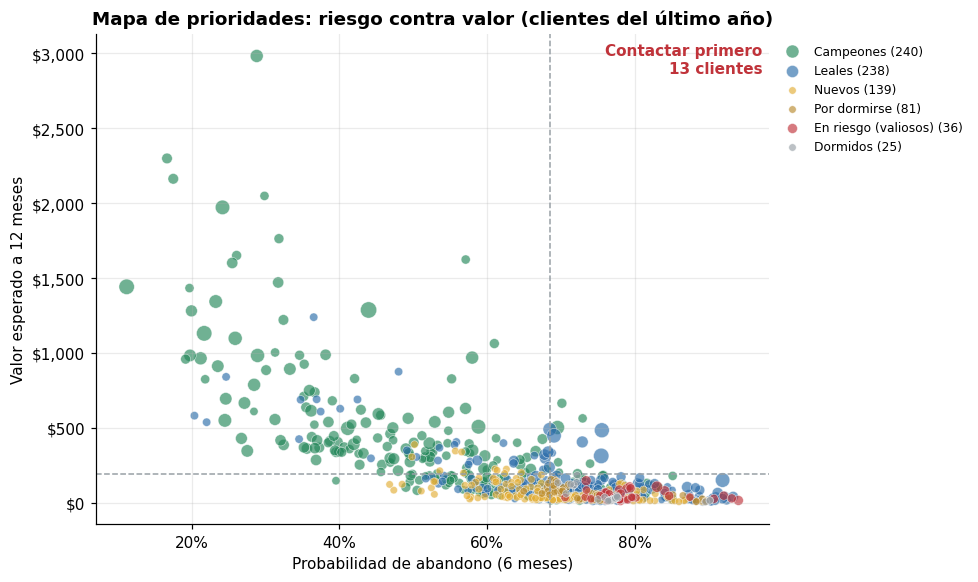

Valor en juego en el cuadrante prioritario: $5,133 en los próximos 12 meses.


Cliente,Teléfono,visitas,recencia_dias,prob_abandono,valor_12m
Fernando Torres Sánchez,5564542672,4,86,70%,$664
Elena Medina López,5599259688,3,40,73%,$563
Alberto Rivera Méndez,5518798161,11,88,70%,$502
Arturo Vázquez Morales,5557974202,10,209,68%,$491
Raúl Flores Vázquez,5518970536,13,249,76%,$484
Guadalupe Jiménez Vázquez,5599852809,12,204,69%,$448
Diana Martínez Gutiérrez,5543468570,7,240,73%,$406
Rafael Herrera Ortiz,5543246993,2,44,69%,$333


In [11]:
activos = hoy[hoy["recencia_dias"] <= 365].copy()
umbral_valor, umbral_riesgo = activos["valor_12m"].quantile(.75), activos["prob_abandono"].median()  # riesgo relativo: la tasa base es alta
prior = activos[(activos["valor_12m"] >= umbral_valor) & (activos["prob_abandono"] >= umbral_riesgo) & (activos["tiene_telefono"] == 1)]

fig, ax = plt.subplots(figsize=(9, 5.4))
colores = {"Campeones": VERDE, "Leales": AZUL, "Nuevos": HILO, "Por dormirse": "#B98A2E", "En riesgo (valiosos)": ROJO, "Dormidos": GRIS}
for s in orden_seg:
    d = activos[activos["segmento"] == s]
    ax.scatter(d["prob_abandono"], d["valor_12m"], s=18 + d["visitas"] * 6, alpha=.65, color=colores[s], label=f"{s} ({len(d)})", edgecolor="white", lw=.4)
ax.axvline(umbral_riesgo, color=GRIS, ls="--", lw=1); ax.axhline(umbral_valor, color=GRIS, ls="--", lw=1)
ax.text(.99, .98, f"Contactar primero\n{len(prior)} clientes", transform=ax.transAxes, ha="right", va="top", fontsize=10, color=ROJO, fontweight="bold")
ax.set_xlabel("Probabilidad de abandono (6 meses)"); ax.set_ylabel("Valor esperado a 12 meses")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, 0)); ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.set_title("Mapa de prioridades: riesgo contra valor (clientes del último año)"); ax.legend(frameon=False, fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout(); plt.show()

# Lista accionable: se puede cargar como campaña en el sistema
nombres_cli = rep.sort_values("Recibido").groupby("cliente_id").agg(Cliente=("Cliente", "last"), Teléfono=("Teléfono", "last"))
lista = prior.join(nombres_cli)[["Cliente", "Teléfono", "visitas", "recencia_dias", "prob_abandono", "valor_12m"]].sort_values("valor_12m", ascending=False)
lista.to_csv("lista_para_campana.csv", index=False, encoding="utf-8-sig")
print(f"Valor en juego en el cuadrante prioritario: ${lista['valor_12m'].sum():,.0f} en los próximos 12 meses.")
display(lista.head(8).style.format({"prob_abandono": "{:.0%}", "valor_12m": "${:,.0f}"}).hide(axis="index"))

## 5. Pronóstico de demanda semanal

Saber cuántos trabajos vienen permite reforzar el taller antes de las semanas saturadas que, como vimos, generan retrasos y clientes perdidos. Para planear (contratar un ayudante temporal, comprar material, ajustar las fechas de entrega) no sirve saber solo la próxima semana: se necesita ver **varias semanas adelante**.

Evalúo los pronósticos a 1, 4 y 8 semanas de anticipación con **validación de origen móvil** sobre las últimas 30 semanas: cada pronóstico se hace usando solo los datos disponibles en ese momento. Como referencia incluyo el **límite por azar**: aunque se conociera exactamente la demanda esperada, el número de clientes que llega cada semana varía de forma natural (proceso de Poisson), y ningún modelo puede bajar de ese error.

,1 sem.,4 sem.,8 sem.
Semana anterior,4.97,5.63,6.87
Promedio últimas 8 semanas,4.70,5.52,5.94
Modelo estacional,5.07,5.47,5.60
Límite por azar (Poisson),4.14,4.14,4.14


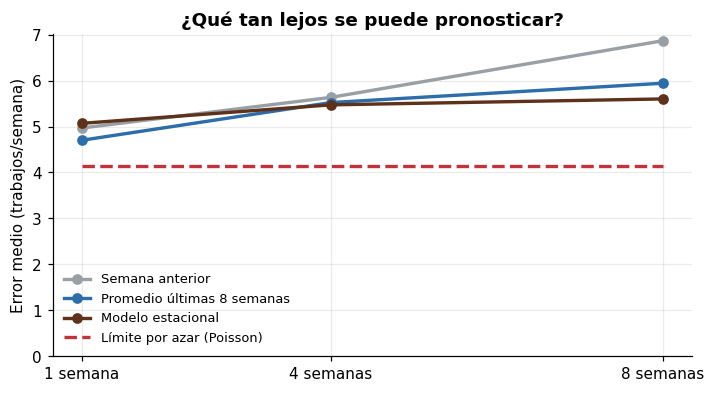

In [12]:
from sklearn.linear_model import Ridge

serie = rep.set_index("Recibido").resample("W-MON", label="left", closed="left").size().iloc[1:-1]  # sin semanas incompletas

def estacional(idx):
    """Variables de calendario: ondas anuales (Fourier) que capturan la temporada."""
    d = pd.DataFrame(index=idx); t = idx.dayofyear / 365.25
    for k in (1, 2):
        d[f"sen{k}"], d[f"cos{k}"] = np.sin(2 * np.pi * k * t), np.cos(2 * np.pi * k * t)
    return d

Xs = estacional(serie.index)
modelo_est = lambda: make_pipeline(StandardScaler(), Ridge(alpha=1.0))
VALID, HORIZONTES = 30, (1, 4, 8)
err = {}
for H in HORIZONTES:
    pr = {"Semana anterior": [], "Promedio últimas 8 semanas": [], "Modelo estacional": []}; real = []
    for i in range(len(serie) - VALID, len(serie)):
        o = i - H + 1                       # solo se conocen las semanas anteriores a `o`
        real.append(serie.iloc[i])
        pr["Semana anterior"].append(serie.iloc[o - 1])
        pr["Promedio últimas 8 semanas"].append(serie.iloc[o - 8:o].mean())
        pr["Modelo estacional"].append(modelo_est().fit(Xs.iloc[:o], serie.iloc[:o]).predict(Xs.iloc[[i]])[0])
    real = np.array(real)
    for m, v in pr.items():
        err.setdefault(m, {})[f"{H} sem."] = np.mean(np.abs(real - np.array(v)))
    err.setdefault("Límite por azar (Poisson)", {})[f"{H} sem."] = np.mean(np.sqrt(2 * real / np.pi))
err = pd.DataFrame(err).T
display(err.style.format("{:.2f}").highlight_min(axis=0, subset=pd.IndexSlice[err.index[:-1], :], color="#E4F4EC")
        .set_caption("Error absoluto medio (trabajos por semana)"))

fig, ax = plt.subplots(figsize=(7.5, 3.8))
for (m, fila), c in zip(err.iterrows(), [GRIS, AZUL, CAFE, ROJO]):
    ax.plot(HORIZONTES, fila.values, "o-" if "Límite" not in m else "--", color=c, lw=2.2, label=m)
ax.set_xticks(HORIZONTES, [f"{h} semana{'s' if h > 1 else ''}" for h in HORIZONTES]); ax.set_ylabel("Error medio (trabajos/semana)")
ax.set_title("¿Qué tan lejos se puede pronosticar?"); ax.legend(frameon=False, fontsize=8.5); ax.set_ylim(0, None); plt.show()

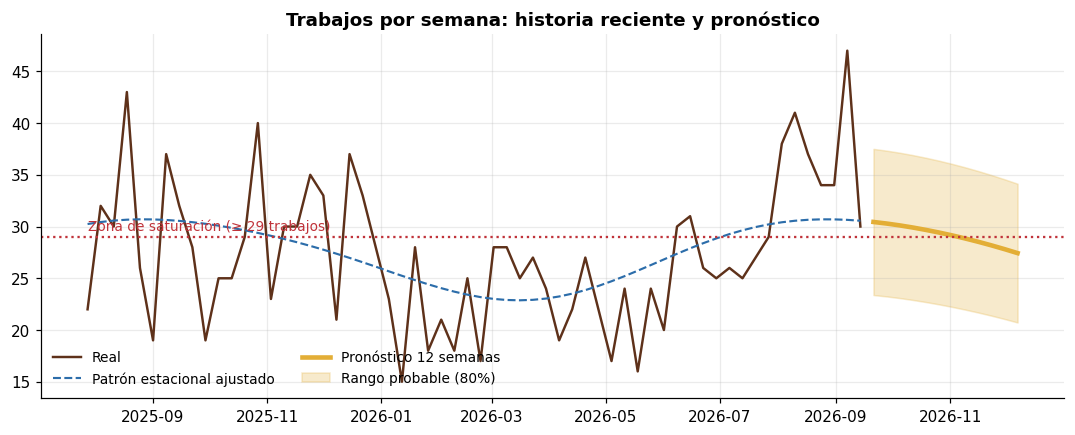

Probabilidad de entrar en zona de saturación, próximas 12 semanas:
  21 Sep: 63%  28 Sep: 62%  05 Oct: 60%  12 Oct: 59%  19 Oct: 57%  26 Oct: 56%  02 Nov: 54%  09 Nov: 51%  16 Nov: 49%  23 Nov: 46%  30 Nov: 44%  07 Dec: 41%
Semanas a vigilar (probabilidad ≥ 40%): 21 Sep, 28 Sep, 05 Oct, 12 Oct, 19 Oct, 26 Oct, 02 Nov, 09 Nov, 16 Nov, 23 Nov, 30 Nov, 07 Dec


In [13]:
# Pronóstico de las próximas 12 semanas con el modelo estacional, entrenado con toda la historia
fut_idx = pd.date_range(serie.index[-1] + pd.Timedelta(weeks=1), periods=12, freq="W-MON")
m = modelo_est().fit(Xs, serie)
fc = pd.Series(m.predict(estacional(fut_idx)), index=fut_idx)
lo, hi = fc - 1.28 * np.sqrt(fc), fc + 1.28 * np.sqrt(fc)        # intervalo del 80% por la variación natural
umbral = carga.loc[carga["nivel"] == "Alta", "trabajos"].min()     # desde aquí se disparan los retrasos (sección 2)

fig, ax = plt.subplots(figsize=(12, 4.3))
ult = serie.iloc[-60:]
ax.plot(ult.index, ult.values, color=CAFE, lw=1.6, label="Real")
ax.plot(serie.index[-60:], m.predict(Xs.iloc[-60:]), color=AZUL, lw=1.4, ls="--", label="Patrón estacional ajustado")
ax.plot(fc.index, fc.values, color=HILO, lw=3, label="Pronóstico 12 semanas")
ax.fill_between(fc.index, lo, hi, color=HILO, alpha=.25, label="Rango probable (80%)")
ax.axhline(umbral, color=ROJO, ls=":", lw=1.5); ax.text(ult.index[0], umbral + .6, f"Zona de saturación (≥ {umbral} trabajos)", color=ROJO, fontsize=9)
ax.set_title("Trabajos por semana: historia reciente y pronóstico"); ax.legend(frameon=False, ncol=2, fontsize=9, loc="lower left"); plt.show()

from scipy.stats import poisson
p_sat = pd.Series(poisson.sf(umbral - 1, fc), index=fc.index)   # P(llegan ≥ umbral trabajos)
print("Probabilidad de entrar en zona de saturación, próximas 12 semanas:")
print("  " + "  ".join(f"{d:%d %b}: {p:.0%}" for d, p in p_sat.items()))
print(f"Semanas a vigilar (probabilidad ≥ 40%): " + (", ".join(f"{d:%d %b}" for d in p_sat[p_sat >= .4].index) or "ninguna"))

**Lectura del pronóstico.** A una semana, el mejor método es *promedio últimas 8 semanas* con un error de ±4.7 trabajos, cerca del límite por azar (±4.1): la variación semana a semana es en su mayoría ruido natural y no vale la pena complicarse. A ocho semanas, el mejor es *modelo estacional* (±5.6), y es ahí donde el patrón estacional aporta: la semana anterior deja de ser una buena guía cuando se acerca agosto o diciembre.

Para el negocio, la herramienta útil es el **calendario de temporada**: saber con dos meses de anticipación cuándo el taller va a entrar en zona de saturación.

## 6. Conclusiones y recomendaciones para el negocio

1. **Priorizar por valor, no solo por riesgo.** Para decidir a quién escribir, los días sin venir ya dan casi toda la información; pero no todos los clientes en riesgo valen lo mismo. La lista `lista_para_campana.csv` combina riesgo y valor esperado: 13 clientes que concentran $5,133 de ingreso probable.
2. **Proteger la puntualidad en temporada alta.** Agosto y diciembre saturan el taller, la saturación produce retrasos y los retrasos se asocian con clientes perdidos. Con el calendario de temporada se puede reforzar el taller (ayudante temporal, fechas de entrega más holgadas) *antes* de que llegue la ola.
3. **Cuidar a los "Campeones"**: concentran el 60% del valor futuro. El programa de lealtad del sistema está dirigido justamente a ellos.
4. **Pedir siempre el WhatsApp.** Cada nota sin teléfono es un cliente que no se puede recuperar.
5. **Usar la temporada baja (enero y febrero)** para campañas de reactivación de clientes dormidos, cuando el taller tiene capacidad libre.

### Limitaciones
- **Datos simulados.** Los resultados validan el método, no el negocio. Los efectos concretos (cuánto aumenta el abandono por un retraso, qué tan marcada es la estacionalidad) deben confirmarse con datos reales.
- **Asociación no es causa.** El vínculo entre retrasos y abandono es consistente con una relación causal, pero para afirmarlo haría falta un experimento, por ejemplo: priorizar la puntualidad en semanas alternas y comparar.
- **Clientes sin teléfono** se identifican por nombre, lo que puede unir a dos personas homónimas o separar a una misma persona escrita de dos formas.

### Próximos pasos
1. Con 6 a 9 meses de datos reales, volver a ejecutar el notebook y comparar los hallazgos con los simulados.
2. Medir el efecto real de las campañas del sistema (el módulo de Marketing ya registra quién regresó tras cada mensaje) como prueba A/B: contactar solo a la mitad de los clientes en riesgo y comparar.
3. Integrar la probabilidad de abandono en el sistema, para que el grupo "en riesgo" de Marketing use el modelo en vez de reglas fijas.

---
*Cómo reproducirlo:* `pip install -r requirements.txt`, luego `python simular_datos.py` y ejecutar este notebook. Para usar datos reales, exporta los CSV desde el sistema (Ajustes → Respaldos), colócalos en `datos/` y ajusta `HOY` a la fecha de exportación.